In [1]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [3]:
data = pd.read_csv(config['data']['clean']['file3'], quotechar='"', sep = ";")

In [4]:
data.nunique(), data.dtypes
#age, education, previous and balance_log need to be scaled

(age                       77
 education                  4
 default                    2
 housing                    2
 loan                       2
 previously_contacted       2
 balance_negative           2
 balance_log             7168
 job_blue-collar            2
 job_entrepreneur           2
 job_housemaid              2
 job_management             2
 job_retired                2
 job_self-employed          2
 job_services               2
 job_student                2
 job_technician             2
 job_unemployed             2
 job_unknown                2
 marital_married            2
 marital_single             2
 dtype: int64,
 age                       int64
 education                 int64
 default                   int64
 housing                   int64
 loan                      int64
 previously_contacted      int64
 balance_negative          int64
 balance_log             float64
 job_blue-collar            bool
 job_entrepreneur           bool
 job_housemaid           

<Axes: xlabel='balance_log'>

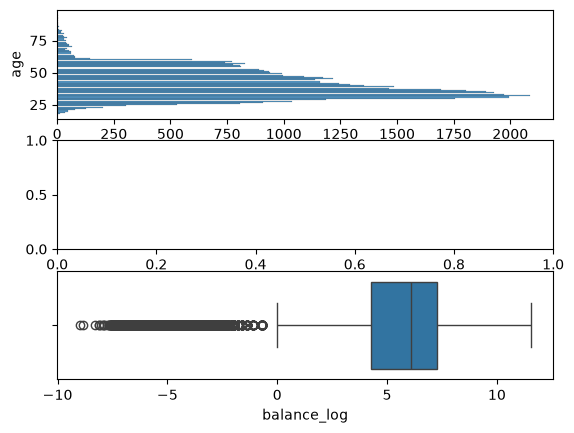

In [5]:
plt.subplots(3,1)
plt.subplot(3,1,1)
sns.histplot(data=data, y='age')
# plt.subplot(3,1,2)
# sns.boxplot(data=data, x='previous')
plt.subplot(3,1,3)
sns.boxplot(data=data, x='balance_log')

In [6]:
# data[data.previous==data.previous.max()]
# # extreme outlier, also didn't convert
# outlier_idx = np.where([data.previous==data.previous.max()])
# data = data.drop(outlier_idx[1])

<Axes: xlabel='balance_log'>

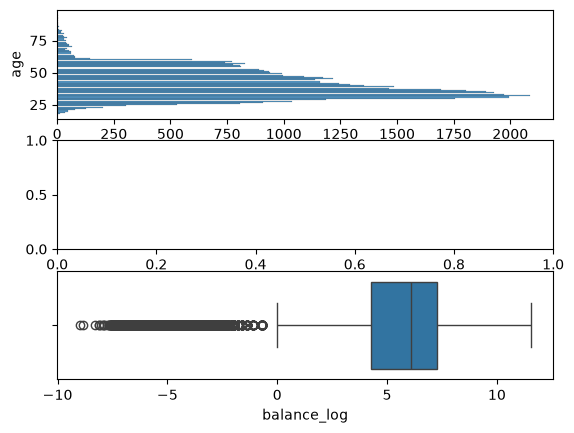

In [7]:
plt.subplots(3,1)
plt.subplot(3,1,1)
sns.histplot(data=data, y='age')
# plt.subplot(3,1,2)
# sns.boxplot(data=data, x='previous')
plt.subplot(3,1,3)
sns.boxplot(data=data, x='balance_log')

In [8]:
data = pd.get_dummies(data, columns=["education"], drop_first=True)

In [9]:
data.columns

Index(['age', 'default', 'housing', 'loan', 'previously_contacted',
       'balance_negative', 'balance_log', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_0', 'education_1', 'education_2'],
      dtype='str')

In [10]:
# features = data.drop(columns=['converted'])
# target = data.converted

In [11]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=0)

In [12]:
#scale for pca
from sklearn.preprocessing import StandardScaler


In [13]:
scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# data_scaled = scaler.fit_transform(data.drop(columns=['converted'])) 

data_scaled = scaler.fit_transform(data) 

# pca = PCA(n_components=...)
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)

In [14]:
from sklearn.decomposition import PCA

In [15]:
data.shape

(45211, 23)

In [16]:
pca = PCA()
pca.fit(data_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >=0.95) +1

In [17]:
d

np.int64(18)

<Axes: >

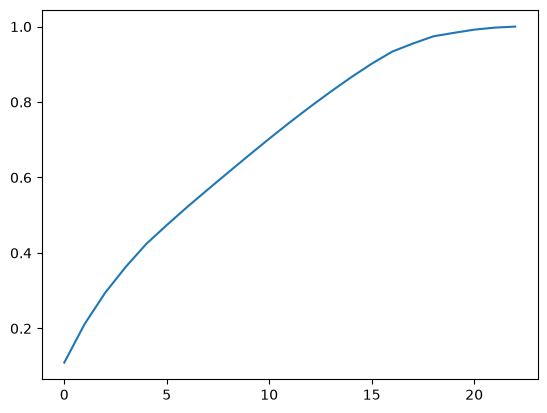

In [18]:
sns.lineplot(cumsum)

In [19]:
# pca = PCA(31) 
# data_pca = pca.fit_transform(data_scaled) 

In [20]:
# from sklearn.cluster import AgglomerativeClustering 
# cluster_model = AgglomerativeClustering(n_clusters=4) 
# data["Clusters"] = cluster_model.fit_predict(data_pca)

In [22]:
from sklearn.cluster import KMeans, HDBSCAN
# k_means = KMeans(n_clusters=4)
# k_means.fit(data_pca)
# y_means = k_means.predict(data_pca)

In [23]:
# from sklearn.cluster import KMeans
# k_means = KMeans(n_clusters=4)
# k_means.fit(data.drop(columns=['converted']))
# y_means = k_means.predict(data.drop(columns=['converted']))

In [24]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters=4)
k_means.fit(data_scaled)
y_means = k_means.predict(data_scaled)

In [ ]:

# centers_original = pd.DataFrame(
#     centers_original,
#     columns=data.columns
# )

# print(centers_original)

In [ ]:

centers_original = pd.DataFrame(
    centers_original,
    columns=data.columns
)

print(centers_original)

In [ ]:
data["cluster"] = y_means

cluster_profile = data.groupby("cluster").mean()

In [ ]:
cluster_profile

In [ ]:
from sklearn.cluster import HDBSCAN
PARAM = ( {"min_cluster_size": 3200},{"min_cluster_size": 3400},{"min_cluster_size": 3600},{"min_cluster_size": 3800})



In [ ]:
PARAM

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, param in enumerate(PARAM):
    hdb = HDBSCAN(copy=True, **param).fit(data_scaled)
    labels = hdb.labels_

    axes[i].scatter(
        data_scaled[:, 0],
        data_scaled[:, 1],
        c=labels,
        cmap="tab10",
        s=10
    )
    axes[i].set_title(str(param))

plt.tight_layout()
plt.show()

In [ ]:
data_scaled.shape, data.shape

In [ ]:
data["cluster"].value_counts()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import HDBSCAN
import numpy as np
PARAM = [
    {"min_cluster_size": 200},
    {"min_cluster_size": 500},
    {"min_cluster_size": 1000},
    {"min_cluster_size": 2000},
    {"min_cluster_size": 3200},
]
results = []

for param in PARAM:
    hdb = HDBSCAN(copy=True, **param).fit(data_scaled)
    labels = hdb.labels_

    # Ignore noise points (-1)
    mask = labels != -1

    # Need at least 2 clusters
    n_clusters = len(set(labels[mask]))

    if n_clusters >= 2:
        score = silhouette_score(
            data_scaled[mask],
            labels[mask]
        )
    else:
        score = np.nan

    results.append((param, score))

results.sort(key=lambda x: x[1], reverse=True)

for param, score in results:
    print(score, param)

In [ ]:
for min_size in [200, 500, 1000, 2000, 3200]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    labels = clusterer.fit_predict(data_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

In [ ]:
# clusterer_cosine = HDBSCAN(min_cluster_size=1000, metric='cosine')
# labels_cosine = clusterer_cosine.fit_predict(data_scaled)
# n_clusters = len(set(labels_cosine)) - (1 if -1 in labels_cosine else 0)
# noise_pct = (labels_cosine == -1).sum() / len(labels_cosine) * 100
# print(f"cosine: {n_clusters} clusters, {noise_pct:.1f}% noise")

In [ ]:
from sklearn.metrics import silhouette_score

for min_size in [200, 500, 1000, 2000, 3200]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    labels = clusterer.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    # Only calculate silhouette on non-noise points
    mask = labels != -1
    score = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else None
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

In [ ]:
from sklearn.cluster import KMeans
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    print(f"k={k}: silhouette={score:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.datasets import make_blobs


def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    # Black removed and is used for noise instead.
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    # The probability of a point belonging to its labeled cluster determines
    # the size of its marker
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]

        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

In [ ]:
X= data_scaled
hdb = HDBSCAN(min_cluster_size=3200).fit(X)
import pandas as pd

pd.Series(hdb.labels_).value_counts()

In [ ]:
data["hdb_cluster"] = hdb.labels_

data.groupby("hdb_cluster").mean(numeric_only=True)

In [ ]:
data.groupby("hdb_cluster")[["housing", "loan", "default"]].mean()